In [1]:
# os 환경 변수 GEMINI API KEY 입력
from dotenv import load_dotenv

load_dotenv()

True

In [6]:
from langchain.chat_models import init_chat_model
from langchain.messages import AnyMessage
from typing_extensions import TypedDict, Annotated
from langgraph.graph.message import add_messages
from langchain.messages import HumanMessage, SystemMessage
from langgraph.graph import StateGraph, START, END


# Store (Long-term Memory)

## Model 정의

In [3]:
model = init_chat_model("gpt-5-nano")

## State 정의

In [4]:
from langchain.messages import AnyMessage
from typing_extensions import TypedDict, Annotated
from langgraph.graph.message import add_messages

class ChatState(TypedDict):
    messages: Annotated[list[AnyMessage], add_messages]

## Node 정의

In [5]:
import uuid
from langgraph.store.base import BaseStore
from langchain.messages import SystemMessage

def memory_agent_node(state: ChatState, config, store: BaseStore):

    # 1. 설정에서 user_id 가져오기 (누구의 기억인가?)
    user_id = config['configurable']['user_id']
    
    # 2. 기억 공간(Namespace) 정의: (사용자ID, 카테고리)
    namespace = (user_id, 'profile')

    # [WRITE] 기억 저장 로직 (간단한 키워드 트리거)
    last_message = state["messages"][-1]
    if "기억해" in last_message.content:
        # store.put(namespace, key, value)
        # key는 고유해야 하므로 uuid 사용
        memory_id = str(uuid.uuid4())
        store.put(
            namespace,
            memory_id,
            {
                'content' : last_message.content
            }

        )
    # [READ] 기억 조회 로직
    memories = store.search(namespace)

    # 기억이 있으면 문자열로 병합
    if memories:
        memory_text = "\n".join([f"- {m.value['content']}" for m in memories])
        system_msg = f"""
        당신은 사용자의 정보를 기억하는 비서입니다.

        [장기 기억 저장소]
        {memory_text}

        위 기억을 참고하여 답변하세요.
        """
    else:
        system_msg = "당신은 도움이 되는 비서입니다. 아직 사용자에 대해 아는 것이 없습니다."

    # 3. LLM 호출 (시스템 메시지 + 대화 내역)
    # SystemMessage를 맨 앞에 끼워넣어서 Context 주입
    prompt = [SystemMessage(content=system_msg)] + state["messages"]

    return {"messages": [model.invoke(prompt)]}

## 그래프 생성

In [7]:
workflow = StateGraph(ChatState)
workflow.add_node("agent", memory_agent_node)
workflow.add_edge(START, "agent")
workflow.add_edge("agent", END)

In [8]:
from langgraph.checkpoint.memory import InMemorySaver

checkpointer = InMemorySaver()

In [10]:
# 장기 기억 (사용자 정보 저장 - DB 역할)
from langgraph.store.memory import InMemoryStore

store = InMemoryStore()


In [11]:
app = workflow.compile(checkpointer=checkpointer, store = store)

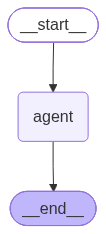

In [12]:
app

## 실행

In [13]:
config_1 = {'configurable': {
    'thread_id': 'store_demo',
    'user_id': 'jay'
}}

In [14]:
input1 = {"messages": [HumanMessage(content="내 이름은 Jay이고, 나는 매운 음식을 싫어해. 이거 꼭 기억해.")]}
resp1 = app.invoke(input1, config_1)

In [15]:
resp1

{'messages': [HumanMessage(content='내 이름은 Jay이고, 나는 매운 음식을 싫어해. 이거 꼭 기억해.', additional_kwargs={}, response_metadata={}, id='de691153-054f-4885-9ec8-d0b6c9176f27'),
  AIMessage(content='확인했습니다, Jay님. 이름은 Jay이고 매운 음식을 싫어한다는 점을 기억하겠습니다. 앞으로 대화에서 매운 음식은 피하고, 필요하면 매운 정도를 먼저 여쭤보겠습니다.\n\n다른 선호나 제약사항이 있으면 알려주세요. 예를 들어 좋아하는 음식 유형, 피해야 할 재료, 알레르기 같은 정보도 함께 반영하겠습니다.', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 805, 'prompt_tokens': 88, 'total_tokens': 893, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 704, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5-nano-2025-08-07', 'system_fingerprint': None, 'id': 'chatcmpl-E93kRW8Pww2EtU6G0DAtXlKKVQC3T', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019fcba5-c499-7d42-a307-4c1620b267a9-0

In [16]:
resp1['messages'][-1].content

'확인했습니다, Jay님. 이름은 Jay이고 매운 음식을 싫어한다는 점을 기억하겠습니다. 앞으로 대화에서 매운 음식은 피하고, 필요하면 매운 정도를 먼저 여쭤보겠습니다.\n\n다른 선호나 제약사항이 있으면 알려주세요. 예를 들어 좋아하는 음식 유형, 피해야 할 재료, 알레르기 같은 정보도 함께 반영하겠습니다.'

In [21]:
config_2 = {"configurable": {"thread_id": "thread-2", "user_id": "jay"}}

In [22]:
input2 = {"messages": [HumanMessage(content="점심 메뉴 추천해줘.")]}
resp2 = app.invoke(input2, config=config_2)

In [23]:
resp2

{'messages': [HumanMessage(content='점심 메뉴 추천해줘.', additional_kwargs={}, response_metadata={}, id='95c6a28e-b59e-402b-9214-62042750b0ce'),
  AIMessage(content='좋아요! 상황이나 취향을 조금만 알려주시면 더 맞춤으로 추천해드릴 수 있는데요, 우선 대중적으로 빠르게 만들 수 있는 메뉴 다섯 가지를 제안드릴게요.\n\n1) 비빔밥 한 그릇\n- 특징: 남은 채소를 한데 모아 고추장 비벼 먹는 한끼\n- 포인트: 계란이나 불고기 추가하면 더 든든\n- 소요 시간: 약 15–20분\n\n2) 매콤 제육덮밥\n- 특징: 돼지고기와 양파를 매콤한 고추장 양념에 볶아 밥 위에 올림\n- 포인트: 야채를 넉넉히 넣으면 식감도 좋고 건강도 챙김\n- 소요 시간: 약 20분\n\n3) 연어덮밥 + 시금치나물\n- 특징: 구운 연어나 구운 생선살 위에 밥을 얹고 간장/참기름 소스\n- 포인트: 단백질 보충에 좋고 비교적 간단\n- 소요 시간: 약 15–20분\n\n4) 크림 파스타(버섯 or 해산물) 혹은 토마토 파스타\n- 특징: 빠르게 만들 수 있는 파스타에 버섯이나 닭고기 추가 가능\n- 포인트: 크림 대신 연두부를 넣으면 가볍게 즐길 수 있음\n- 소요 시간: 약 15–25분\n\n5) 닭가슴살 샐러드볼\n- 특징: 구운 닭가슴살, 다양한 생채소, 현미나 퀴노아 넣고 드레싱\n- 포인트: 가볍지만 영양 균형 좋음\n- 소요 시간: 약 10–15분\n\n추가로 원하시는 것 알려주시면 더 맞춤으로 좁혀드릴게요\n- 예산(예: 1인당 6천원 이하, 1만원대 등)\n- 시간(10분 안에, 20–30분 등)\n- 선호 맛/식단(매운맛, 해산물 가능 여부, 채식 여부)\n- 위치나 주문 여부(근처 맛집 추천도 가능)\n\n원하시는 방향이 있으면 알려주시면 바로 2–3가지로 구체화해 드릴게요.', additional_kwargs={'refusal': None}, 

In [24]:
resp2['messages'][-1].content

' Jay님, 매운 음식 싫어하신다고 기억하고 있어요. 점심 메뉴 중 매운 맛 없이도 즐길 수 있는 5가지 제안드립니다.\n\n1) 구운 연어 덮밥\n- 특징: 구운 연어를 밥 위에 얹고 간장-참기름 소스로 마무리\n- 포인트: 단백질 보충에 좋고 무난한 맛\n- 소요 시간: 약 15–20분\n\n2) 닭가슴살 샐러드볼\n- 특징: 구운 닭가슴살과 다양한 생채소, 현미나 퀴노아 반찬\n- 드레싱: 레몬+올리브오일로 상큼하게\n- 포인트: 가볍고 영양 균형 좋음\n- 소요 시간: 약 10–15분\n\n3) 버섯 크림 파스타\n- 특징: 크림 소스의 부드러운 파스타에 버섯 추가\n- 포인트: 매운맛 없이 진한 맛, 해산물 버전으로도 가능\n- 소요 시간: 약 15–25분\n\n4) 두부 스테이크와 구운 채소\n- 특징: 두부를 구워 채소와 함께 제공\n- 포인트: 채식 옵션으로도 좋고 담백한 맛\n- 소요 시간: 약 15–20분\n\n5) 해물 화이트 소스 파스타\n- 특징: 토마토 소스 대신 크림/화이트 소스로 부드럽게\n- 포인트: 해산물 추가 시 영양 만점\n- 소요 시간: 약 15–25분\n\n원하시면 예산, 남은 시간, 선호 재료에 맞춰 2–3가지로 더 구체화해서 맞춤 추천해 드릴게요.'

## 장기 기억 도구화

In [25]:
from langchain.tools import tool

# 1. 도구(Tool) 정의: AI에게 쥐어줄 '기억 버튼'
@tool
def save_profile(info: str):
    """
    사용자에 대한 중요한 정보(이름, 취미, 특징 등)를 저장할 때 사용합니다.
    단순한 대화나 인사는 저장하지 마세요.
    """
    print(f'저장한 정보 : {info}')
    # 이 함수는 실제로는 실행되지 않고, 스키마(껍데기)만 LLM에게 전달
    # 실제 저장 로직은 아래 'save_node'에서 store 객체를 이용해 수행
    return "saved"

In [26]:
tools = [save_profile]

In [27]:
model_with_tools = model.bind_tools(tools)

In [28]:
from langgraph.store.base import BaseStore

# [Node 1] 에이전트: 대화 및 판단
def agent_node(state: ChatState, config, store: BaseStore):
    user_id = config["configurable"]["user_id"]
    namespace = (user_id, "profile")

    # 1. 저장된 기억을 조회해서 컨텍스트로 주입
    memories = store.search(namespace)
    if memories:
        info = "\n".join([f"- {m.value['data']}" for m in memories])
        system_msg = f"당신은 사용자의 기억을 담당하는 비서입니다.\n[기억된 정보]\n{info}"
    else:
        system_msg = "당신은 사용자의 기억을 담당하는 비서입니다."

    # 2. LLM 호출
    return {"messages": [model_with_tools.invoke([SystemMessage(content=system_msg)] + state["messages"])]}

In [29]:
from langchain.messages import ToolMessage

# [Node 2] 저장 실행기: 실제 Store에 저장 (Action)
def save_node(state: ChatState, config, store: BaseStore):
    user_id = config["configurable"]["user_id"]
    namespace = (user_id, "profile")

    # 에이전트가 보낸 '도구 호출' 메시지 가져오기
    last_message = state["messages"][-1]

    tool_outputs = []
    for tool_call in last_message.tool_calls:
        if tool_call["name"] == "save_profile":
            # AI가 저장하라고 한 정보
            info_to_save = tool_call["args"]["info"]

            print(f"\n💾 [System] AI의 요청으로 정보를 저장합니다: '{info_to_save}'")

            # [Store Write] 실제 저장 수행
            memory_id = str(uuid.uuid4())
            store.put(namespace, memory_id, {"data": info_to_save})

            # 도구 실행 결과 메시지 생성
            tool_outputs.append(
                ToolMessage(
                    content=f"정보 저장 완료: {info_to_save}",
                    tool_call_id=tool_call["id"]
                )
            )

    return {"messages": tool_outputs}

In [31]:
workflow = StateGraph(ChatState)
workflow.add_node("agent", agent_node)
workflow.add_node("save_node", save_node)

workflow.add_edge(START, "agent")

In [33]:
# 조건부 함수
def should_continue(state: ChatState):
    last_message = state['messages'][-1]

    if last_message.tool_calls : 
        return 'save_node'
    else:
        return END


In [34]:
# 조건부 엣지
workflow.add_conditional_edges(
    'agent',
    should_continue,
    ['save_node', END]
)

In [35]:
# save_node가 agent에게 보고 (엣지)
workflow.add_edge("save_node", "agent")

In [36]:
checkpointer = InMemorySaver()
store = InMemoryStore()
app = workflow.compile(checkpointer=checkpointer, store=store)

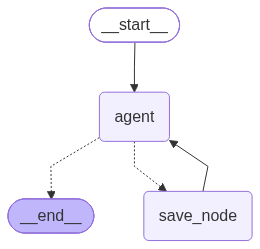

In [37]:
app

In [39]:
config = {"configurable": {"thread_id": "1", "user_id": "jay"}}

In [40]:
# '기억해'라고 강요하지 않아도, 문맥상 정보라고 판단되면 저장함
input1 = {"messages": [HumanMessage(content="안녕, 나는 샌프란시스코에 사는 Jay라고 해.")]}
resp1 = app.invoke(input1, config=config)


💾 [System] AI의 요청으로 정보를 저장합니다: '이름: Jay, 거주지: 샌프란시스코'


In [41]:
resp1

{'messages': [HumanMessage(content='안녕, 나는 샌프란시스코에 사는 Jay라고 해.', additional_kwargs={}, response_metadata={}, id='9fca42f4-80cf-4ec1-ae3a-e7347f999707'),
  AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 486, 'prompt_tokens': 186, 'total_tokens': 672, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 448, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5-nano-2025-08-07', 'system_fingerprint': None, 'id': 'chatcmpl-E93tLybJQDhtuxZR1ATWECj976RAc', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019fcbae-336b-7ae0-9165-fe8b3a290f48-0', tool_calls=[{'name': 'save_profile', 'args': {'info': '이름: Jay, 거주지: 샌프란시스코'}, 'id': 'call_MaHulRXcOdMoAhTYXIeQG6po', 'type': 'tool_call'}], invalid_tool_calls=[], usage_met

In [42]:
resp1["messages"][-1].content

'반가워요, Jay님. 지금 이름은 Jay, 거주지는 샌프란시스코로 기억해두었습니다.\n\n다른 정보를 더 남기고 싶으시면 말씀해 주세요(예: 취미, 선호 장소, 연락처 등). 필요할 때 불러오거나 활용할 수 있도록 도와드릴게요. 무엇부터 저장해볼까요?'

In [43]:
input2 = {"messages": [HumanMessage(content="내 이름이 뭐고 어디 산다고 했지?")]}
resp2 = app.invoke(input2, config=config)

In [44]:
resp2["messages"][-1].content

'당신의 이름은 Jay이고, 거주지는 샌프란시스코입니다. 필요하신 다른 정보도 저장해둘까요? 예: 취미나 선호 장소 등.'